# Week-1: Exploratory Data Analysis: Iris Dataset

**Goal:** Perform a full EDA on the Iris dataset — clean the data, understand each feature, and generate visualizations that reveal patterns in the data, particularly around how the three species differ.

**Dataset:** 150 samples of iris flowers, 4 numeric measurements (sepal length/width, petal length/width in cm) and 1 categorical label (species: setosa, versicolor, virginica).

## 1. Load the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

sns.set_style('whitegrid')

iris_bunch = load_iris(as_frame=True)
df = iris_bunch.frame

df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})
df = df.drop(columns='target')

print("Shape:", df.shape)
df.head()

Shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 2. Inspect & Clean

Before any analysis, we check for the standard data quality issues: missing values, duplicate rows, and implausible values (e.g. negative measurements).

In [2]:
print("Data types:\n", df.dtypes)
print("\nMissing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nSummary statistics:\n", df.describe())
print("\nSpecies counts:\n", df['species'].value_counts())

Data types:
 sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species               object
dtype: object

Missing values per column:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Duplicate rows: 1

Summary statistics:
        sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.0

**Findings from cleaning:**
- No missing values in any column.
- One exact duplicate row exists. This is a known feature of the classic Iris dataset (a duplicated virginica record) rather than a data entry error, so we leave it in rather than dropping it. It still represents a real, plausible measurement.
- All values fall within physically plausible ranges (no negative or zero measurements).
- The three species are perfectly balanced at 50 samples each, which means later visualizations won't be skewed by one class simply having more data points.

## 3. Univariate Analysis

In [3]:
numeric_cols = df.columns[:-1]

print("Skewness (0 = symmetric):\n", df[numeric_cols].skew())
print("\nKurtosis (negative = flatter than normal distribution):\n", df[numeric_cols].kurt())

Skewness (0 = symmetric):
 sepal length (cm)    0.314911
sepal width (cm)     0.318966
petal length (cm)   -0.274884
petal width (cm)    -0.102967
dtype: float64

Kurtosis (negative = flatter than normal distribution):
 sepal length (cm)   -0.552064
sepal width (cm)     0.228249
petal length (cm)   -1.402103
petal width (cm)    -1.340604
dtype: float64


All four features have skewness close to zero, meaning none are heavily lopsided. Petal length and petal width have notably negative kurtosis, which hints they may be bimodal (two separate clusters) rather than a single smooth bell curve, we're gonna confirm this visually next.

## 4. Visualizations

### Visualization 1: Distribution of Each Feature (Histograms)

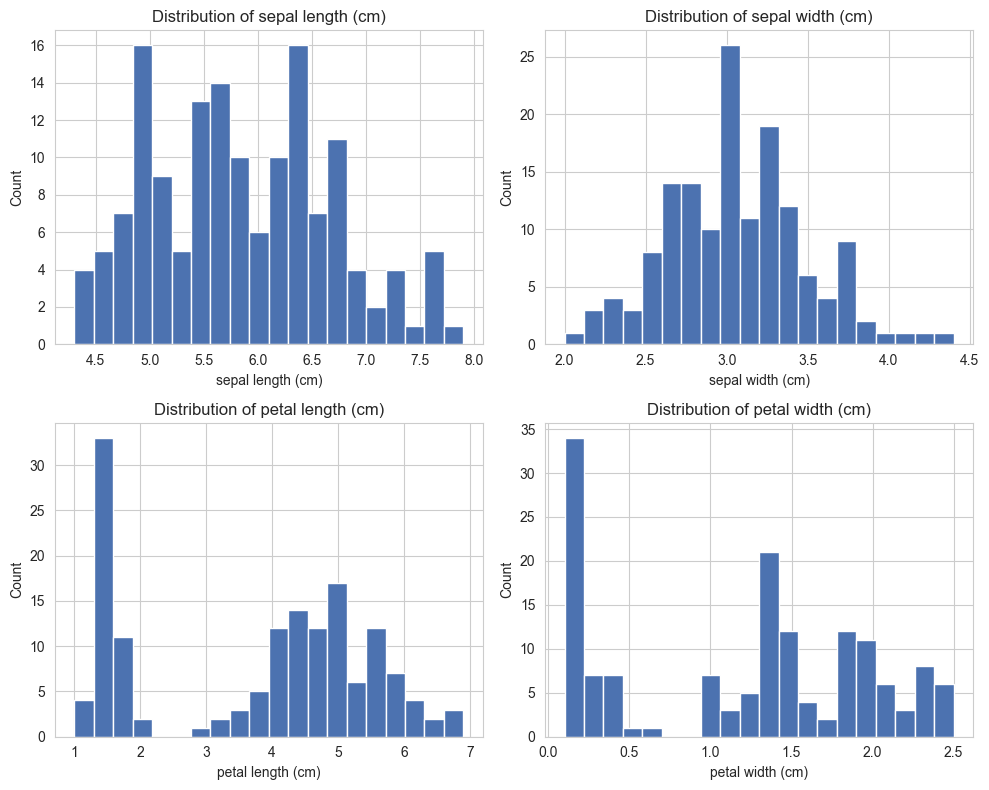

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=20, color='#4C72B0', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

**Observation:** Petal length and petal width are clearly bimodal, a tight low cluster plus a broader high cluster, while sepal length and width look closer to a single unimodal distribution. This suggests petal measurements will be more useful for telling species apart.

### Visualization 2: Feature Distributions by Species (Box Plots)

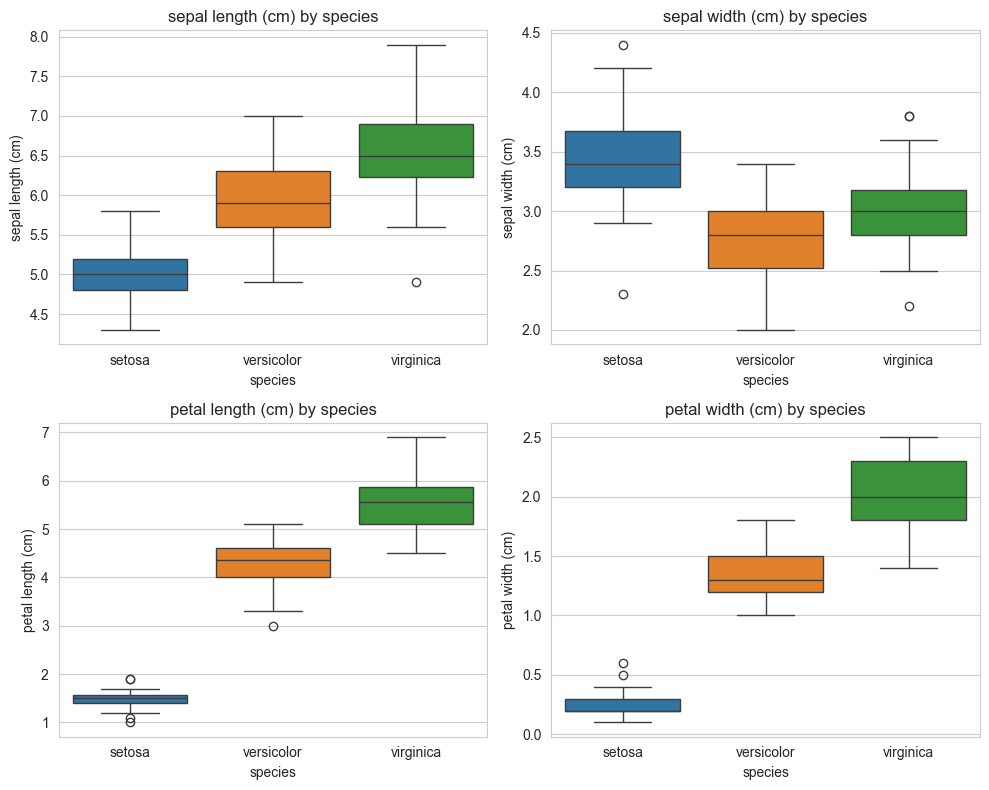

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='species', y=col, ax=axes[i], hue='species', legend=False)
    axes[i].set_title(f'{col} by species')

plt.tight_layout()
plt.show()

**Observation:** Petal length and petal width show almost no overlap between species, setosa especially stands completely apart. Sepal width, in contrast, overlaps heavily across all three species and would be a poor feature on its own for telling them apart. A few mild outliers appear (e.g. one short-sepal virginica) but nothing that looks like a data error.

### Visualization 3: Petal Length vs Petal Width (Scatter Plot)

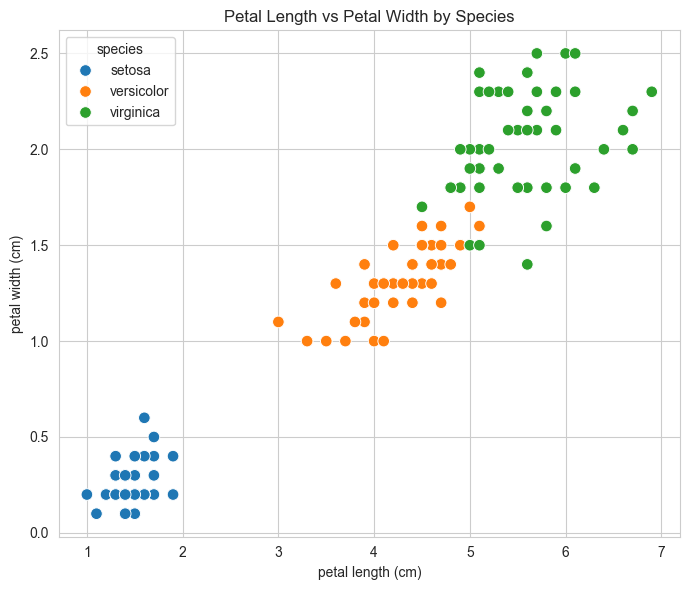

In [6]:
plt.figure(figsize=(7, 6))
sns.scatterplot(data=df, x='petal length (cm)', y='petal width (cm)', hue='species', s=70)
plt.title('Petal Length vs Petal Width by Species')
plt.tight_layout()
plt.show()

**Observation:** Setosa forms a completely isolated cluster, separable from the other two species with a single straight line using just these two features. Versicolor and virginica overlap slightly around petal length ≈ 5cm but are still largely distinguishable.

### Visualization 4: All Pairwise Relationships (Pair Plot)

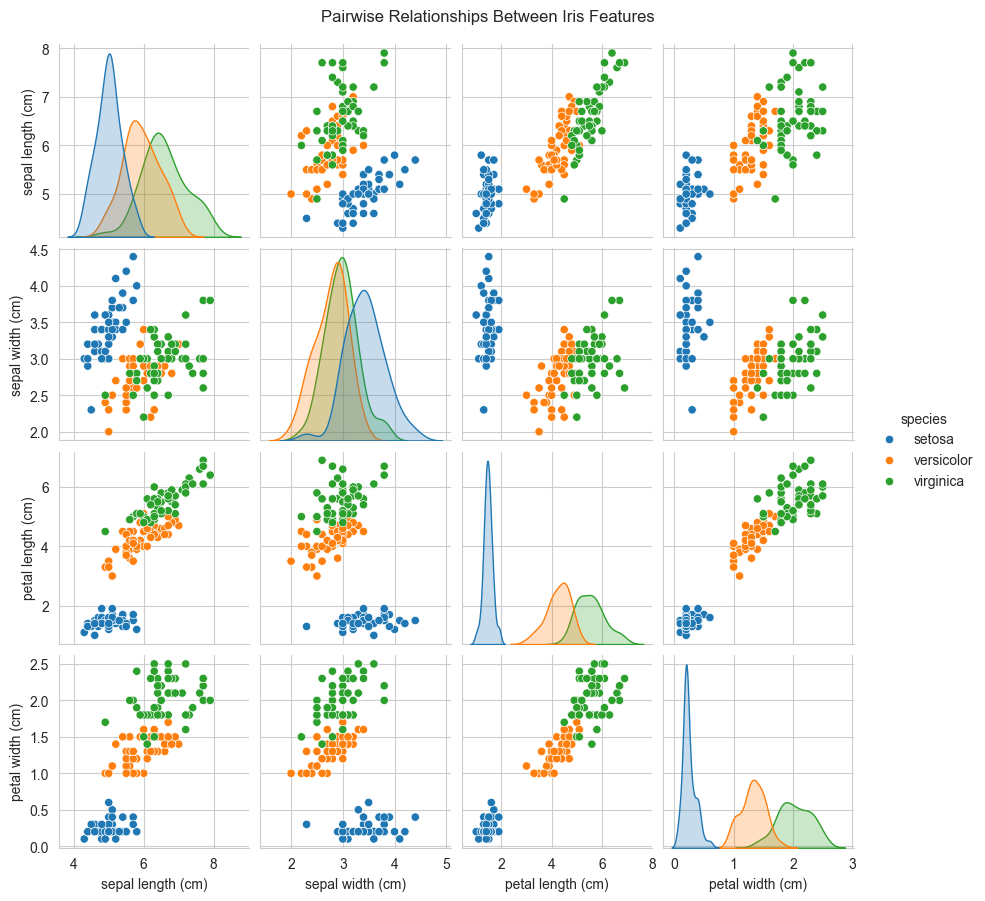

In [7]:
g = sns.pairplot(df, hue='species', diag_kind='kde', height=2.2)
g.fig.suptitle('Pairwise Relationships Between Iris Features', y=1.02)
plt.show()

**Observation:** This confirms the pattern across all feature pairs at once. Any chart involving petal length or petal width shows clean species separation; the sepal-only comparisons (top-left block) show much more overlap. The diagonal density curves explain the earlier bimodal histograms: setosa's distribution sits entirely apart from the other two species on petal measurements.

### Visualization 5: Correlation Between Features (Heatmap)

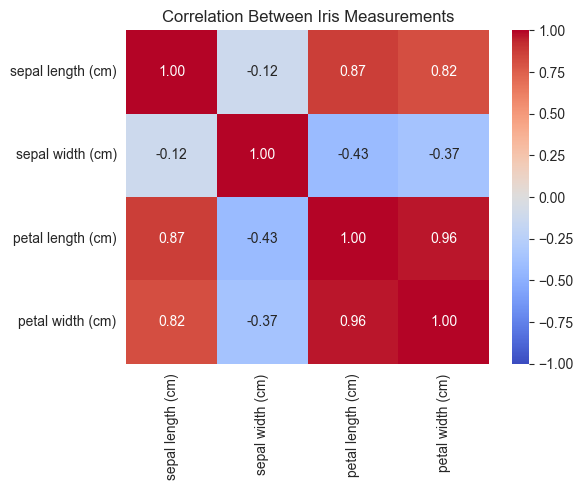

In [8]:
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Between Iris Measurements')
plt.tight_layout()
plt.show()

**Observation:** Petal length and petal width are very strongly correlated (r = 0.96) larger flowers tend to scale proportionally in both dimensions. Sepal width stands out as the only feature with a negative correlation to the others, reinforcing that it behaves differently from the rest of the measurements.

## 5. Summary of Findings

1. **Data quality:** The dataset is clean, no missing values, all measurements within plausible ranges, and perfectly balanced classes (50 samples per species). One duplicate row exists but appears to be a genuine repeated measurement rather than an error.
2. **Petal measurements are far more discriminative than sepal measurements.** Petal length and petal width nearly perfectly separate the three species, while sepal width in particular overlaps heavily across species and would be a weak classifier on its own.
3. **Setosa is the most distinct species**. it forms an isolated cluster on almost every feature pair, especially petal length/width, making it the easiest of the three species to identify.
4. **Versicolor and virginica are more similar to each other** than either is to setosa, with some overlap in petal measurements around the boundary between them.
5. **Petal length and petal width are highly correlated (r = 0.96)**, suggesting that for many modeling purposes, the two carry overlapping information.

These findings suggest that any future classification model for this data should prioritize petal length and width as the primary features, since they carry the most species-discriminating signal.